In [1]:
# we analyze the NTK which is rotation invariant, so we first compare the functional dependence in rho (correlation or dot product)

import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal
from jax import random
from tqdm import tqdm

In [2]:

# we define the NTK formula functions
def get_rho_eff(rho, beta, norm_x=1.0, norm_x_prime=1.0):
    numerator = rho + beta**2  # we compute numerator
    denominator = jnp.sqrt((norm_x**2 + beta**2) * (norm_x_prime**2 + beta**2))  # we compute denominator
    return numerator / denominator

def K1(rho_eff, beta, norm_x=1.0, norm_x_prime=1.0):
    rho_eff = jnp.clip(rho_eff, -1.0, 1.0)  # we avoid domain errors for arccos
    variance_product = jnp.sqrt((norm_x**2 + beta**2) * (norm_x_prime**2 + beta**2))
    term_in_parentheses = jnp.sqrt(1 - rho_eff**2) + (jnp.pi - jnp.arccos(rho_eff)) * rho_eff
    return variance_product * (1 / (2 * jnp.pi)) * term_in_parentheses

def K_dot(rho_eff):
    rho_eff = jnp.clip(rho_eff, -1.0, 1.0)  # we avoid domain errors for arccos
    return (1 / (2 * jnp.pi)) * (jnp.pi - jnp.arccos(rho_eff))

def ntk_formula(rho, beta, norm_x=1.0, norm_x_prime=1.0):
    rho_eff = get_rho_eff(rho, beta, norm_x, norm_x_prime)  # we compute effective correlation
    k1_val = K1(rho_eff, beta, norm_x, norm_x_prime)  # we compute K1 term
    k_dot_val = K_dot(rho_eff)  # we compute K_dot term
    return k1_val + (rho + beta**2) * k_dot_val


In [3]:
def I_0(mu, rho):
    """
    Computes I_0 = P(Z > -mu, Z' > -mu) for a bivariate normal distribution
    with correlation rho.
    By symmetry, equals P(Z < mu, Z' < mu).
    """
    rho = jnp.clip(rho, -0.9999, 0.9999)  # we handle edge cases
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]
    # we use scipy's multivariate normal since jax doesn't have cdf
    return multivariate_normal.cdf([mu, mu], mean=mean, cov=cov)

def I_1(mu, rho):
    """
    Computes I_1 = (1+rho) * phi(-mu) * Phi(-mu * sqrt((1-rho)/(1+rho)))
    """
    rho = jnp.clip(rho, -0.9999, 0.9999)  # we handle edge cases
    a = -mu
    factor = jnp.sqrt((1 - rho) / (1 + rho))
    # we use scipy's normal distribution
    return (1 + rho) * norm.pdf(a) * norm.cdf(a * factor)

def I_2(mu, rho):
    """
    Computes I_2 = rho * I_0 + (1-rho^2) * phi(-mu, -mu; rho)
    """
    rho = jnp.clip(rho, -0.9999, 0.9999)  # we handle edge cases
    a = -mu
    i0_val = I_0(mu, rho)
    # we use scipy's multivariate normal
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]
    pdf_val = multivariate_normal.pdf([a, a], mean=mean, cov=cov)
    return rho * i0_val + (1 - rho**2) * pdf_val

def inner_expectation(mu, rho):
    """
    Computes inner expectation I(mu, rho) = I_2 + 2*mu*I_1 + mu^2*I_0
    """
    sigma = 1.0  # we assume sigma=1 since Q1, Q2 are standard
    i0 = I_0(mu, rho)
    i1 = I_1(mu, rho)
    i2 = I_2(mu, rho)
    return sigma**2 * i2 + 2 * mu * sigma * i1 + mu**2 * i0

def two_layer_ntk(rho):
    """
    Computes the 2-layer NTK formula K(ρ) = (1/2π)(sqrt(1-ρ^2) + (π-arccos(ρ))ρ) + ρ*(1/2π)(π-arccos(ρ))
    """
    term1 = jnp.sqrt(1 - rho**2)
    term2 = (jnp.pi - jnp.arccos(rho)) * rho
    term3 = rho * (jnp.pi - jnp.arccos(rho))
    return (1/(2*jnp.pi)) * (term1 + term2) + (1/(2*jnp.pi)) * term3


In [4]:
def calculate_total_expectation_riemann(beta, rho, n_points=1000):
    """
    Computes total expectation E_b[I(b*beta, rho)] using Riemann sum with Gaussian weights.
    We integrate over [-5,5] which covers >99.99% of normal distribution.
    """
    b_points = jnp.linspace(-5, 5, n_points)  # we create grid points for b
    db = b_points[1] - b_points[0]  # we compute step size
    gaussian_weights = norm.pdf(b_points)  # we compute Gaussian weights
    expectations = jnp.array([inner_expectation(b * beta, rho) for b in tqdm(b_points, desc="Computing Riemann sum", leave=False)])  # we compute expectation for each b
    return jnp.sum(expectations * gaussian_weights * db)  # we return weighted sum

In [ ]:
import json  # we import json module
import os  # we import os module for path handling

rhos = jnp.linspace(-0.99, 0.99, 50)  # we use 20 points for reasonable computation
betas = [0, 0.3, 0.5, 1.0,1.2,1.5, 2.0]  # we test different beta values
n_riemann_points = 50  # we set number of points for Riemann sum

total_I_values_per_beta = []  # we store values for each beta
data_to_save = {"rhos": rhos.tolist(), "data": []}  # we create dict to store data

for beta in tqdm(betas, desc="Computing expectations for different betas"):
    beta_values = []  # we store values for current beta
    for rho in tqdm(rhos, desc=f"Computing rho values for beta={beta}", leave=True):
        beta_values.append(calculate_total_expectation_riemann(beta, rho, n_riemann_points))  # we compute Riemann sum expectation for each rho
    total_I_values_per_beta.append(beta_values)  # we append the full list for this beta
    data_to_save["data"].append({"beta": beta, "values": beta_values})  # we store beta and its values


Computing expectations for different betas:   0%|          | 0/7 [00:00<?, ?it/s]
































































































































































































































































































































































































































































































Computing expectations for different betas:  14%|█▍        | 1/7 [00:52<05:15, 52.56s/it]






























































































































































































































































































































































TypeError: Object of type ArrayImpl is not JSON serializable

In [6]:

# Create directory if it doesn't exist
save_dir = "/home/janis/STG3A/MMNN/experiments/data/ntk_values/2layers"  # we set save directory
os.makedirs(save_dir, exist_ok=True)  # we create directory if it doesn't exist
# Save data to JSON file
save_path = os.path.join(save_dir, "ntk_values.json")  # we create full save path
with open(save_path, 'w') as f:
    # Convert JAX arrays to regular Python lists before saving
    data_to_save["rhos"] = [float(x) for x in data_to_save["rhos"]]  # we convert rhos to float list
    for item in data_to_save["data"]:
        item["values"] = [float(x) for x in item["values"]]  # we convert values to float list
    json.dump(data_to_save, f)  # we save all data to json file


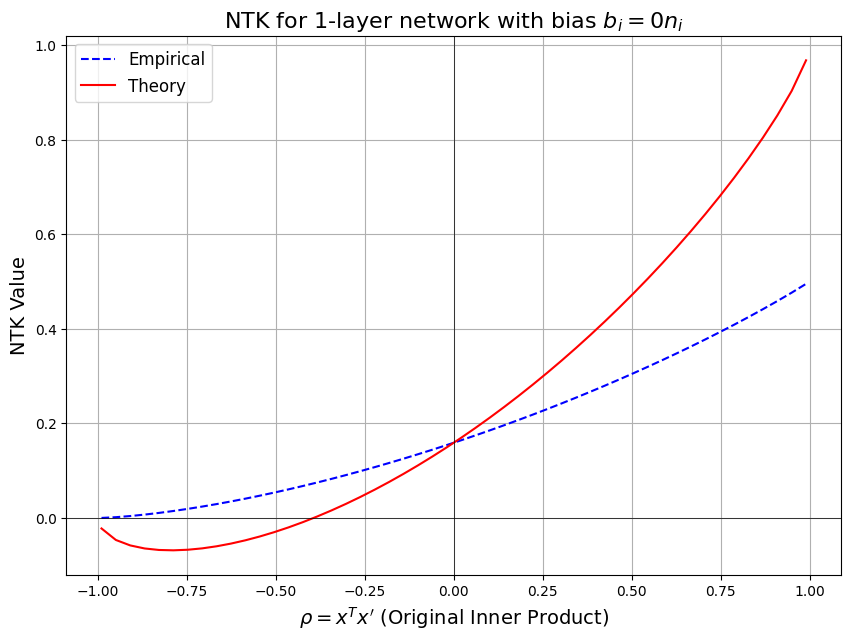

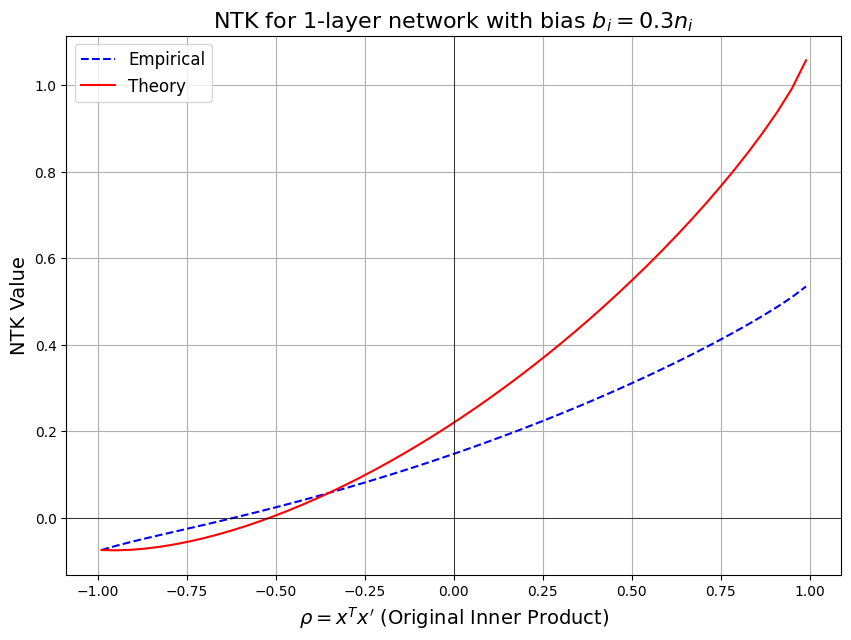

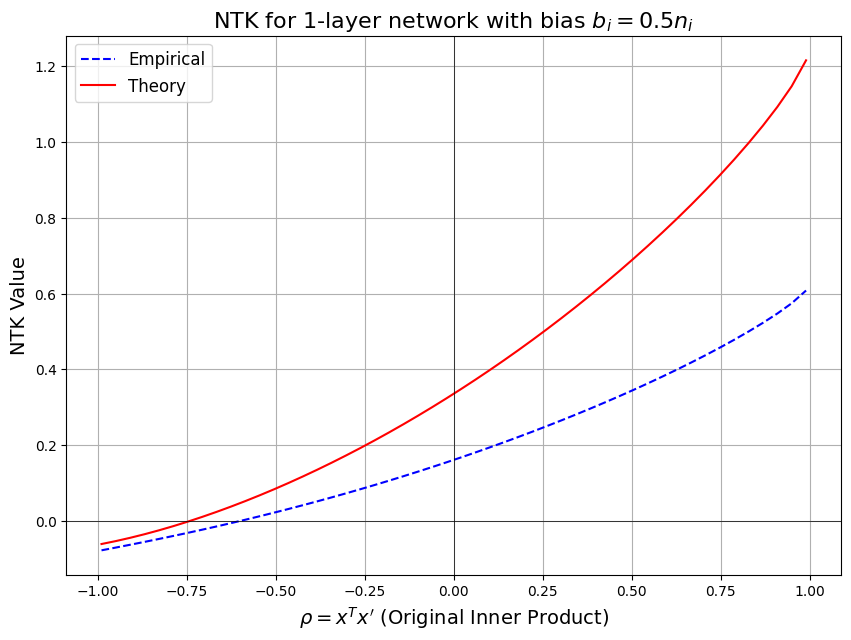

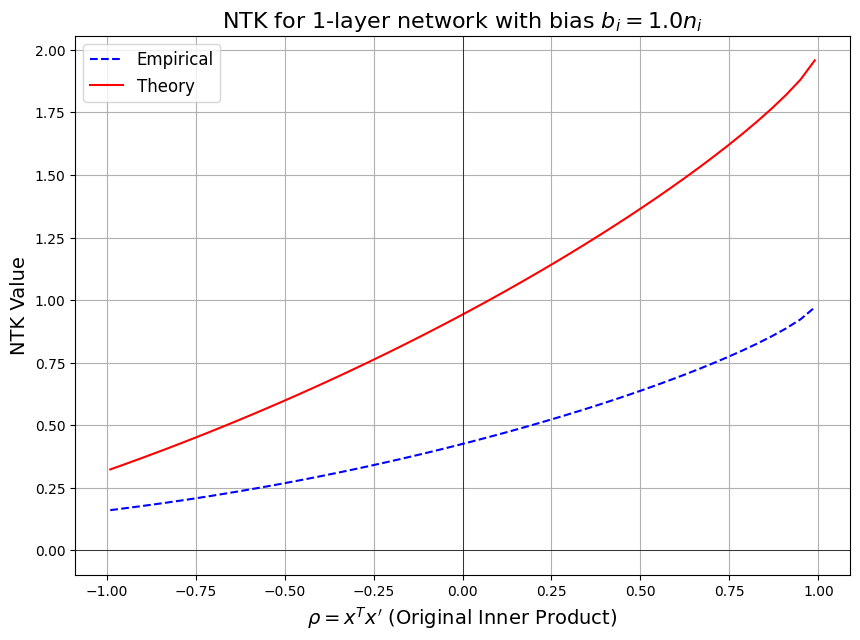

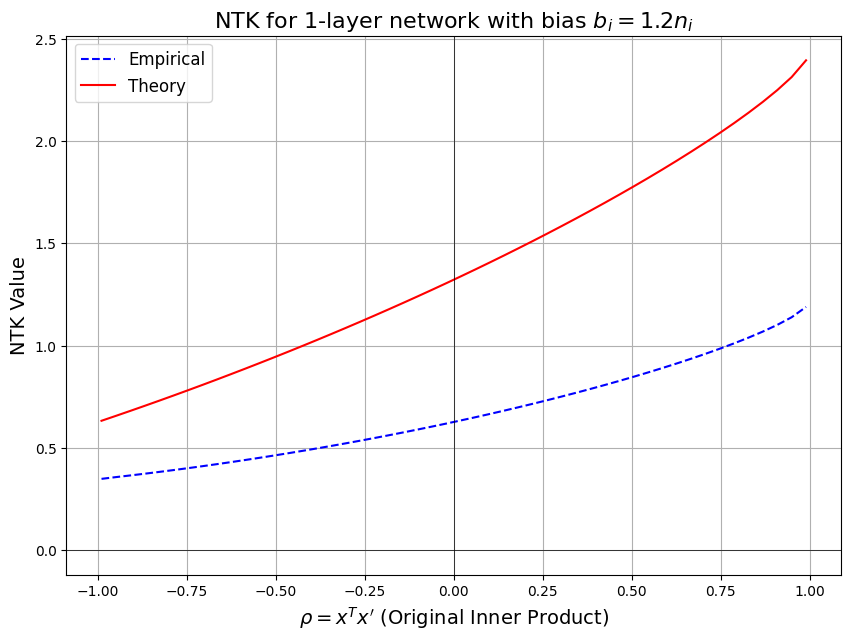

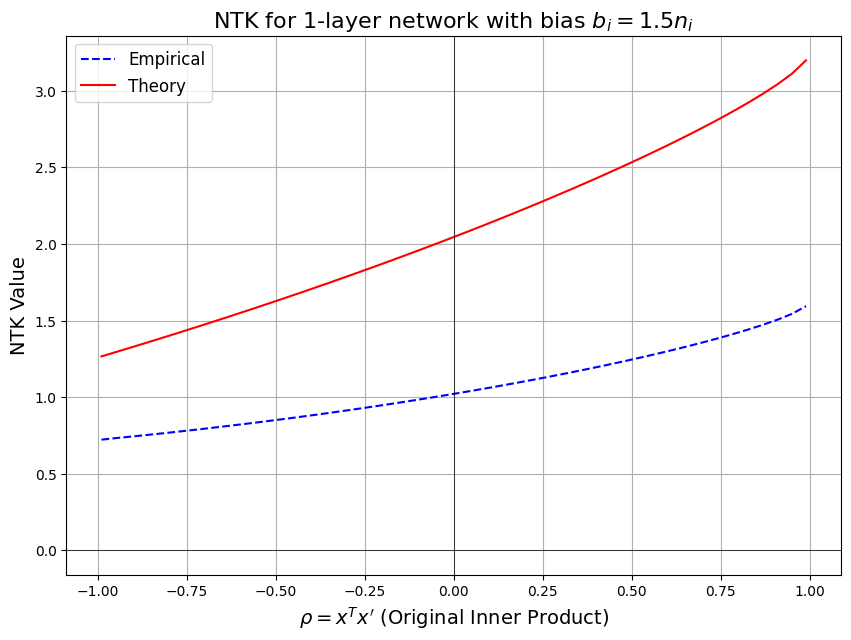

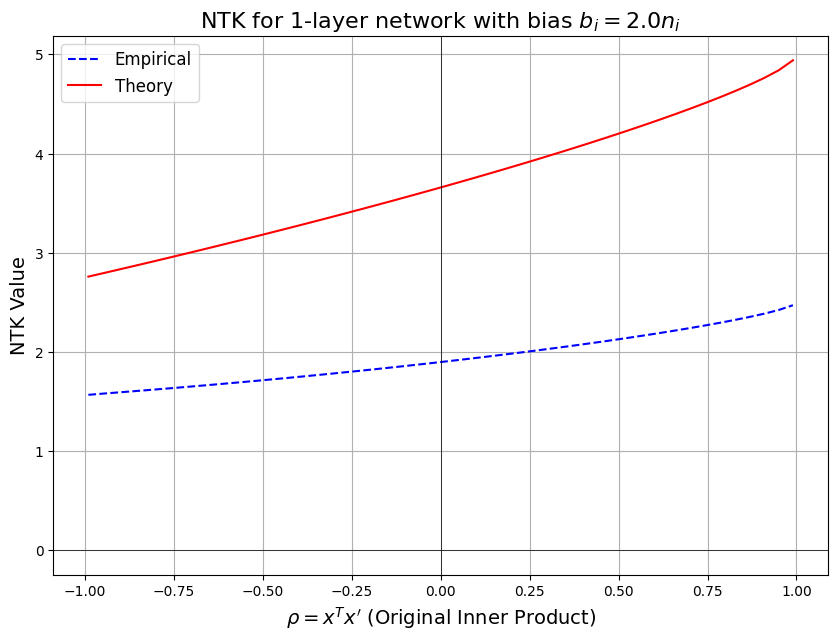

In [7]:
# Load saved data
save_dir = "/home/janis/STG3A/MMNN/experiments/data/ntk_values/2layers"  # we set save directory
save_path = os.path.join(save_dir, "ntk_values.json")  # we create full save path

with open(save_path, 'r') as f:
    loaded_data = json.load(f)  # we load data from json file

rhos = jnp.array(loaded_data["rhos"])  # we get rho values
betas = [data["beta"] for data in loaded_data["data"]]  # we get beta values
total_I_values_per_beta = [data["values"] for data in loaded_data["data"]]  # we get computed values

# Create a figure for each beta value
for beta_idx, beta in enumerate(betas):
    plt.figure(figsize=(10, 7))  # we create new figure for each beta
    
    # Empirical values from loaded data
    plt.plot(rhos, total_I_values_per_beta[beta_idx], '--', color='blue', label='Empirical')  # we plot empirical values
    
    # Theoretical values 
    ntk_values = [ntk_formula(rho, beta) for rho in rhos]  # we compute theoretical NTK values
    plt.plot(rhos, ntk_values, '-', color='red', label='Theory')  # we plot theoretical values

    plt.xlabel('$\\rho = x^T x\'$ (Original Inner Product)', fontsize=14)
    plt.ylabel('NTK Value', fontsize=14)
    plt.title(f'NTK for 1-layer network with bias $b_i = {beta}n_i$', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.axhline(0, color='black', linewidth=0.5)  # we add horizontal line at y=0
    plt.axvline(0, color='black', linewidth=0.5)  # we add vertical line at x=0
    plt.show()

# %%


Computing spectra for n=8, beta=0: 100%|██████████| 50/50 [00:37<00:00,  1.32it/s]


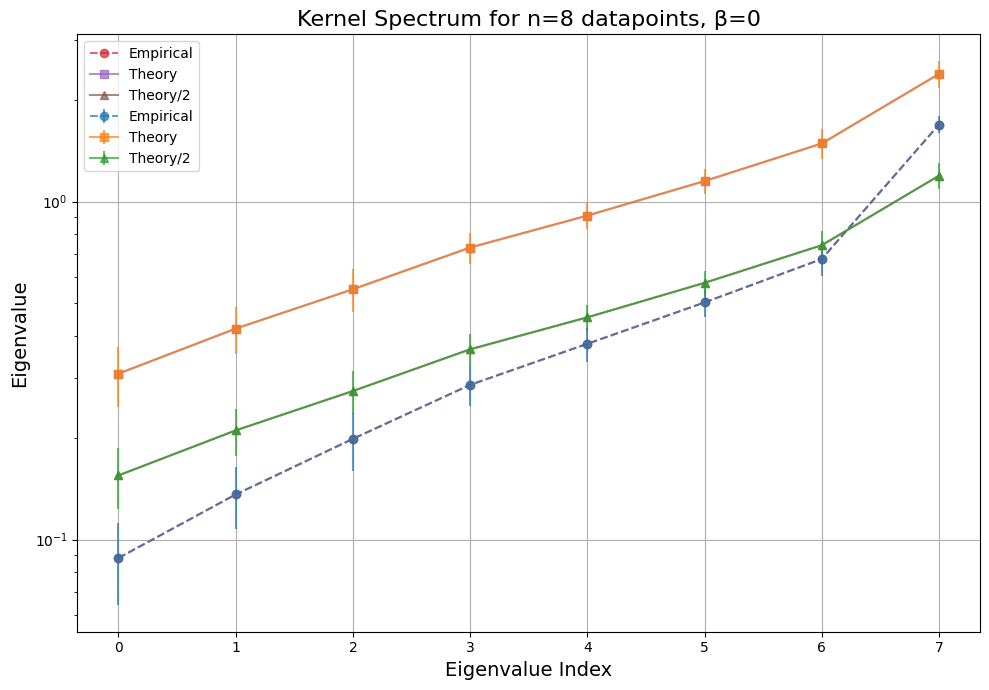

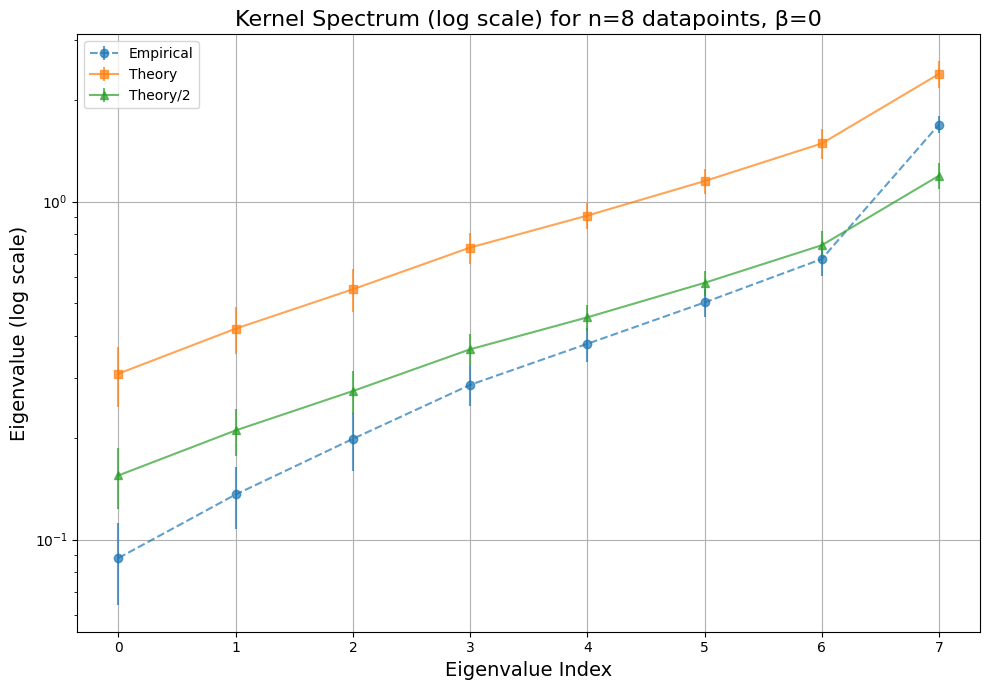

Computing spectra for n=8, beta=0.3: 100%|██████████| 50/50 [00:37<00:00,  1.34it/s]


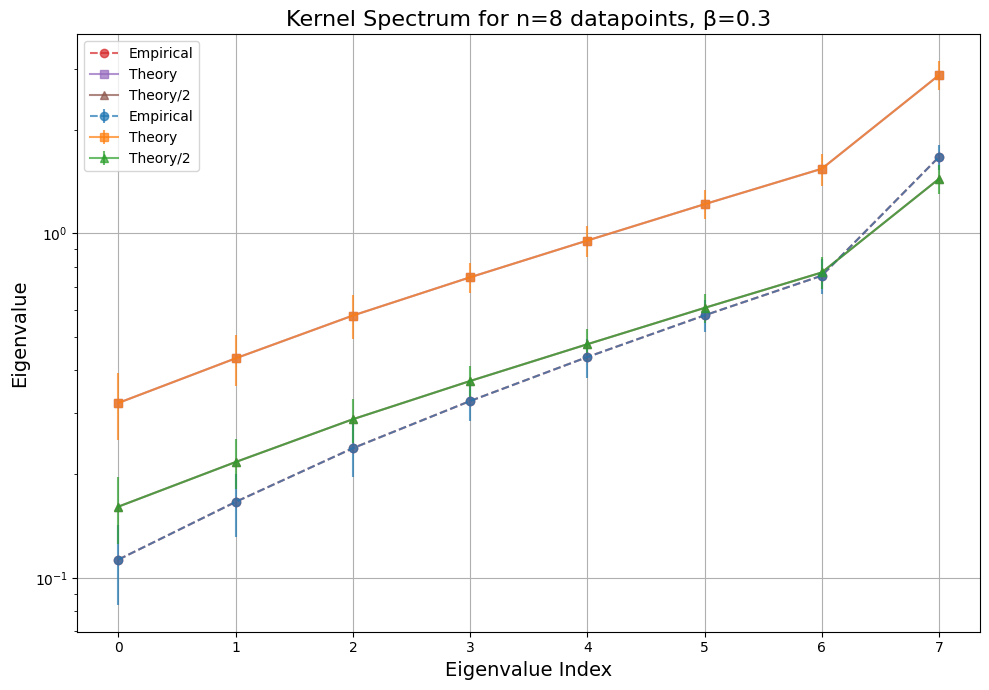

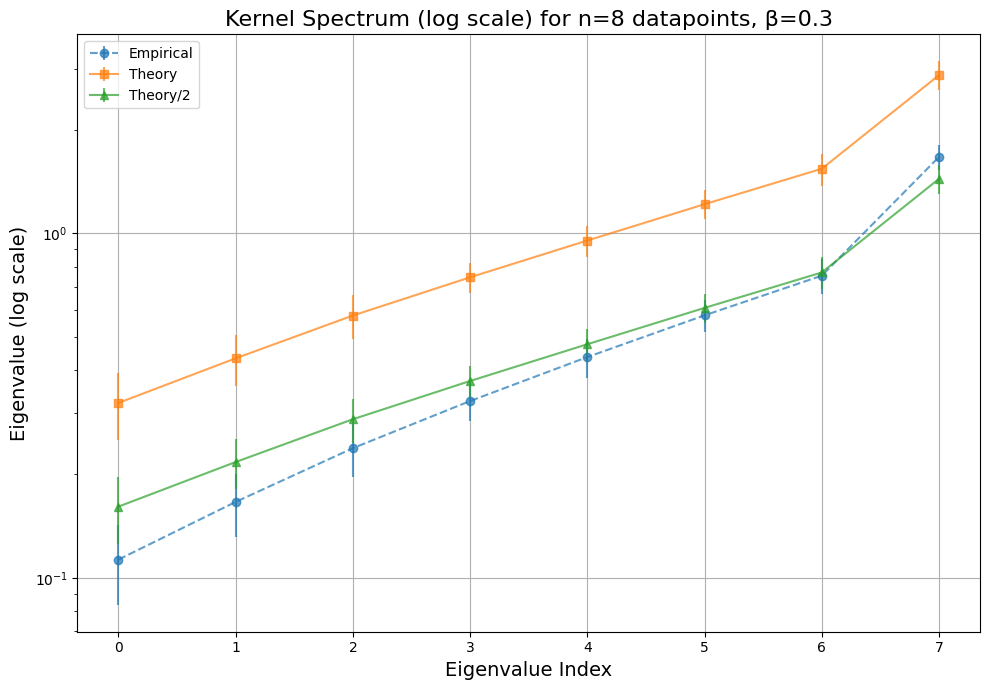

Computing spectra for n=8, beta=0.5:  94%|█████████▍| 47/50 [00:36<00:02,  1.29it/s]


KeyboardInterrupt: 

In [ ]:
# Generate random vectors on unit sphere and compute kernels
d = 10  # we set dimension of vectors
n_samples = [8, 16]  # we set number of data points to test 
n_trials = 50  # we set number of trials for computing std
key = random.PRNGKey(0)  # we set random seed

for n in n_samples:
    for beta in betas:
        
        
        empirical_spectra = []  # we store eigenvalues for empirical kernel
        theory_spectra = []  # we store eigenvalues for theoretical kernel
        
        for trial in tqdm(range(n_trials), desc=f"Computing spectra for n={n}, beta={beta}"):
            # Generate random vectors on sphere
            key, subkey = random.split(key)
            X = random.normal(subkey, (n, d))  # we generate random gaussian vectors
            X = X / jnp.linalg.norm(X, axis=1, keepdims=True)  # we normalize to unit sphere
            
            # Compute gram matrix
            gram = X @ X.T  # we compute inner products
            
            # Empirical kernel
            empirical_kernel = jnp.zeros((n, n))  # we initialize empirical kernel matrix
            for i in range(n):
                for j in range(n):
                    # Find nearest rho in grid
                    rho = gram[i,j]
                    rho_idx = jnp.argmin(jnp.abs(rhos - rho))  # we find closest rho in grid
                    beta_idx = betas.index(beta)  # we get index of current beta
                    empirical_kernel = empirical_kernel.at[i,j].set(total_I_values_per_beta[beta_idx][rho_idx])  # we set kernel value
            
            # Theoretical kernel
            theory_kernel = jnp.array([[ntk_formula(gram[i,j], beta) for j in range(n)] for i in range(n)])  # we compute theoretical kernel
            
            # Compute eigenvalues
            empirical_eigs = jnp.linalg.eigvalsh(empirical_kernel)  # we compute eigenvalues for empirical
            theory_eigs = jnp.linalg.eigvalsh(theory_kernel)  # we compute eigenvalues for theoretical
            
            empirical_spectra.append(empirical_eigs)
            theory_spectra.append(theory_eigs)
        
        # Convert to arrays and compute statistics
        empirical_spectra = jnp.array(empirical_spectra)  # we convert to array
        theory_spectra = jnp.array(theory_spectra)  # we convert to array
        
        emp_mean = jnp.mean(empirical_spectra, axis=0)  # we compute mean eigenvalues
        emp_std = jnp.std(empirical_spectra, axis=0)  # we compute std of eigenvalues
        theory_mean = jnp.mean(theory_spectra, axis=0)  # we compute mean eigenvalues
        theory_std = jnp.std(theory_spectra, axis=0)  # we compute std of eigenvalues
        
        # Plot with error bars
        x = jnp.arange(n)  # we create x-axis points
        
        plt.figure(figsize=(10, 7))  # we create new figure for each beta and n
        plt.errorbar(x, emp_mean, yerr=emp_std, fmt='o--', 
                    label='Empirical', alpha=0.7)  # we plot empirical with error bars
        plt.errorbar(x, theory_mean, yerr=theory_std, fmt='s-',
                    label='Theory', alpha=0.7)  # we plot theoretical with error bars
        plt.errorbar(x, theory_mean/2, yerr=theory_std/2, fmt='^-',
                    label='Theory/2', alpha=0.7)  # we plot theoretical/2 with error bars
    
    
      
        plt.xlabel('Eigenvalue Index', fontsize=14)
        plt.ylabel('Eigenvalue', fontsize=14)
        plt.title(f'Kernel Spectrum for n={n} datapoints, β={beta}', fontsize=16)
        plt.legend(fontsize=10)
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        # Plot with error bars in log scale for y-axis
        plt.figure(figsize=(10, 7))  # we create new figure for log y-axis plot
        plt.errorbar(x, emp_mean, yerr=emp_std, fmt='o--', 
                    label='Empirical', alpha=0.7)  # we plot empirical with error bars
        plt.errorbar(x, theory_mean, yerr=theory_std, fmt='s-',
                    label='Theory', alpha=0.7)  # we plot theoretical with error bars
        plt.errorbar(x, theory_mean/2, yerr=theory_std/2, fmt='^-',
                    label='Theory/2', alpha=0.7)  # we plot theoretical/2 with error bars
        
        plt.yscale('log')  # we set y-axis to log scale
        plt.xlabel('Eigenvalue Index', fontsize=14)
        plt.ylabel('Eigenvalue (log scale)', fontsize=14)
        plt.title(f'Kernel Spectrum (log scale) for n={n} datapoints, β={beta}', fontsize=16)
        plt.legend(fontsize=10)
        plt.grid(True)
        plt.tight_layout()
        plt.show()
